# 1.0 Import Libraries & Data

In [36]:
import pandas as pd
from extra.utils import load_config
import mlflow
from pycaret.classification import *
from pycaret.regression import *

In [37]:
cfg = load_config()

Config loaded successfully!

data:
  raw_path: ../data/raw/smart_manufacturing_data.csv
  interim_path: ../data/interim/cleaned.csv
  processed_path: ../data/processed/features.csv
  target_column: maintenance_required
cleaning: null
features:
  rolling_window_size: 5
  sensor_columns:
  - temperature
  - vibration
  - humidity
  - pressure
  - energy_consumption
model:
  n_jobs: 2
  session_id: 42
  train_size: 0.8
  ignore_features:
  - failure_type
  - downtime_risk
  - anomaly_flag
  - machine_status
  - predicted_remaining_life
mlflow:
  tracking_uri: http://127.0.0.1:5000
  experiment_name: Smart Manufacturing Maintenance



In [38]:
df_cleaned = pd.read_csv(cfg.data.interim_path, parse_dates=["timestamp"])
df_feat = pd.read_csv(cfg.data.processed_path, parse_dates=["timestamp"])

# Lesser rows now because I clipped the imcomplete data out.
print(df_cleaned.shape)
print(df_feat.shape)

(99360, 13)
(99360, 21)


In [39]:
def train_model(data, name, target):
    exp = ClassificationExperiment()

    exp.setup(
        data=data,
        target=target,
        session_id=cfg.model.session_id,
        train_size=cfg.model.train_size,
        ignore_features=cfg.model.ignore_features,
        experiment_name=f"{cfg.mlflow.experiment_name}_{name}",
        log_experiment=True,
        html=False,
        verbose=False
    )

    model = exp.compare_models(verbose=False)
    results = exp.pull().copy()

    return exp, model, results

In [40]:
cleaned_exp, cleaned_model, cleaned_results = train_model(df_cleaned, "cleaned_only", cfg.data.target_column)

2026/07/27 20:26:39 INFO mlflow.tracking._tracking_service.client: 🏃 View run Session Initialized 455d at: http://127.0.0.1:5000/#/experiments/609383072842183230/runs/fae4b12c2cd5494e8b972a499a810c67.
2026/07/27 20:26:39 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/609383072842183230.
2026/07/27 20:28:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/07/27 20:28:02 INFO mlflow.tracking._tracking_service.client: 🏃 View run Random Forest Classifier at: http://127.0.0.1:5000/#/experiments/907385899181641041/runs/98037dd5b10349699eb4d3d2d4c01d16.
2026/07/27 20:28:02 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/907385899181641041.
2026/07/27 20:28:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set 

In [41]:
print("=== Cleaned Only ===")
print(cleaned_results)

=== Cleaned Only ===
                                 Model  Accuracy     AUC  Recall   Prec.  \
rf            Random Forest Classifier    0.8925  0.7292  0.4544  0.9990   
gbc       Gradient Boosting Classifier    0.8925  0.7280  0.4544  0.9987   
ada               Ada Boost Classifier    0.8924  0.7295  0.4543  0.9987   
et              Extra Trees Classifier    0.8903  0.7335  0.4479  0.9888   
knn             K Neighbors Classifier    0.8652  0.7186  0.4088  0.8143   
nb                         Naive Bayes    0.8504  0.7240  0.2586  0.9330   
svm                SVM - Linear Kernel    0.8321  0.6968  0.2238  0.5222   
lr                 Logistic Regression    0.8316  0.6971  0.1509  0.9602   
lda       Linear Discriminant Analysis    0.8308  0.6971  0.1461  0.9630   
ridge                 Ridge Classifier    0.8095  0.6971  0.0323  1.0000   
qda    Quadratic Discriminant Analysis    0.8031  0.0000  0.0000  0.0000   
dummy                 Dummy Classifier    0.8031  0.5000  0.0000  0

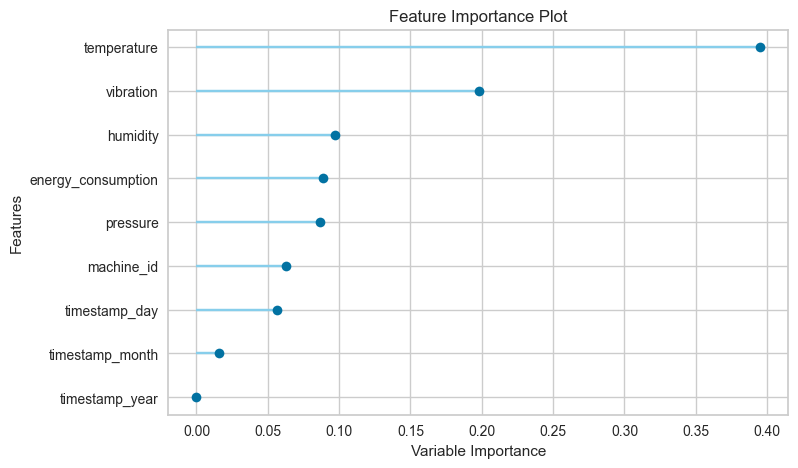

In [42]:
cleaned_exp.plot_model(cleaned_model, plot="feature")


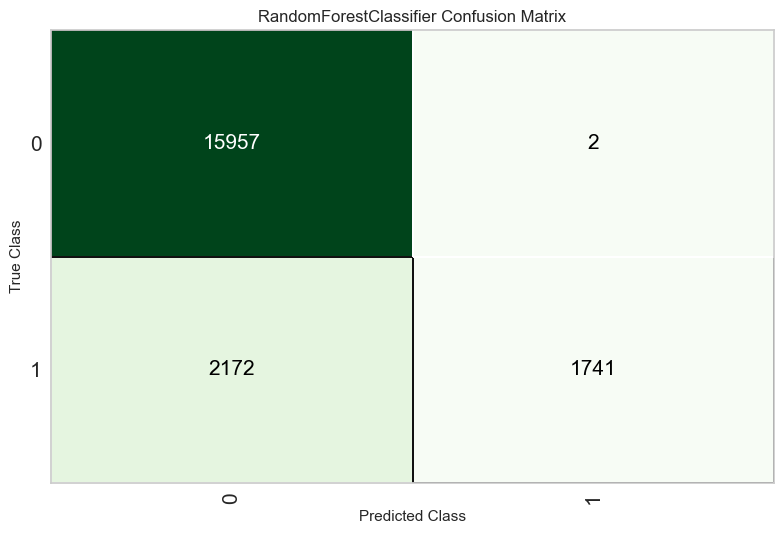

In [43]:
cleaned_exp.plot_model(cleaned_model, plot="confusion_matrix")

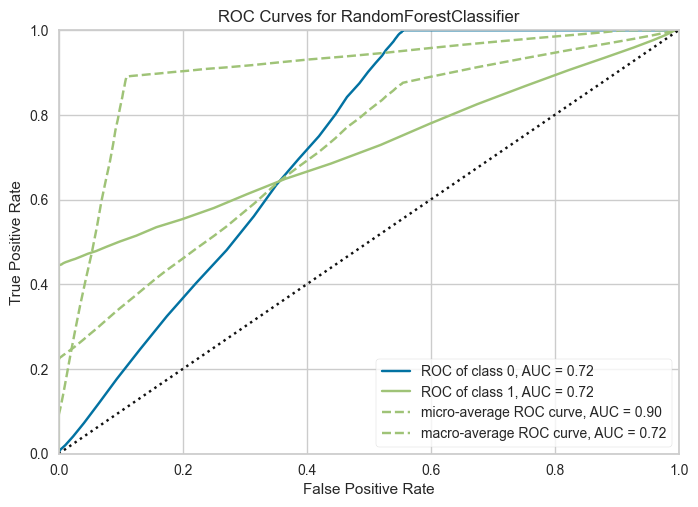

In [47]:
cleaned_exp.plot_model(cleaned_model, plot="auc")

In [44]:
eng_exp, eng_model, eng_results = train_model(df_feat, "feature_engineered", cfg.data.target_column)

2026/07/27 20:32:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/07/27 20:32:26 INFO mlflow.tracking._tracking_service.client: 🏃 View run Random Forest Classifier at: http://127.0.0.1:5000/#/experiments/609383072842183230/runs/bf4b054db00e44309a0a9a861fb433fe.
2026/07/27 20:32:26 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/609383072842183230.
2026/07/27 20:32:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/07/27 20:32:27 INFO mlflow.tracking._tracking_service.client: 🏃 View run Ada Boost Classifier at: http://127.0.0.1:5000/#/experiments/609383072842183230/runs/78d30b3f1bde45f88b36dcdc4d5af99b.
2026/07/27 20:32:27 INFO mlflow.tracking._tracking_service.client

In [45]:
print("\n=== Feature Engineered ===")
print(eng_results)


=== Feature Engineered ===
                                 Model  Accuracy     AUC  Recall   Prec.  \
rf            Random Forest Classifier    0.8922  0.7290  0.4529  0.9989   
ada               Ada Boost Classifier    0.8921  0.7290  0.4529  0.9982   
gbc       Gradient Boosting Classifier    0.8921  0.7306  0.4529  0.9983   
et              Extra Trees Classifier    0.8898  0.7293  0.4495  0.9798   
lda       Linear Discriminant Analysis    0.8281  0.6997  0.1275  0.9950   
knn             K Neighbors Classifier    0.8277  0.6623  0.2503  0.6662   
lr                 Logistic Regression    0.8268  0.7139  0.1206  1.0000   
nb                         Naive Bayes    0.8110  0.7149  0.5043  0.5208   
ridge                 Ridge Classifier    0.8078  0.6997  0.0237  1.0000   
qda    Quadratic Discriminant Analysis    0.8031  0.0000  0.0000  0.0000   
dummy                 Dummy Classifier    0.8031  0.5000  0.0000  0.0000   
dt            Decision Tree Classifier    0.7957  0.6951  0.

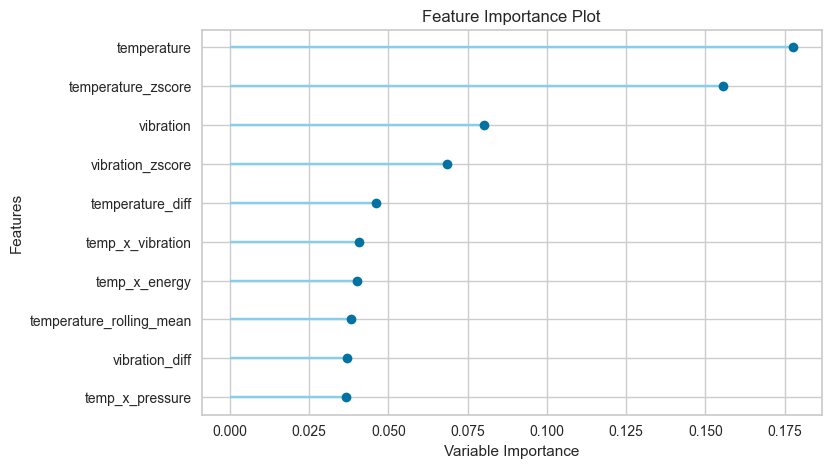

In [46]:
eng_exp.plot_model(eng_model, plot="feature")

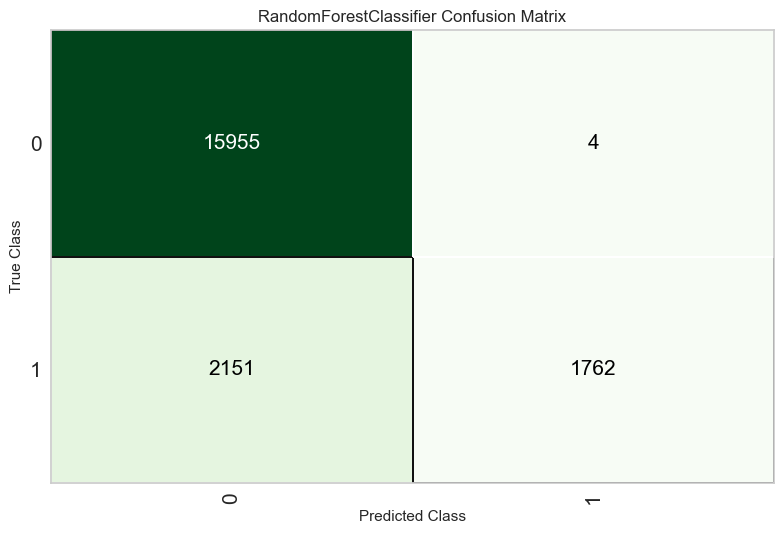

In [49]:
eng_exp.plot_model(eng_model, plot="confusion_matrix")

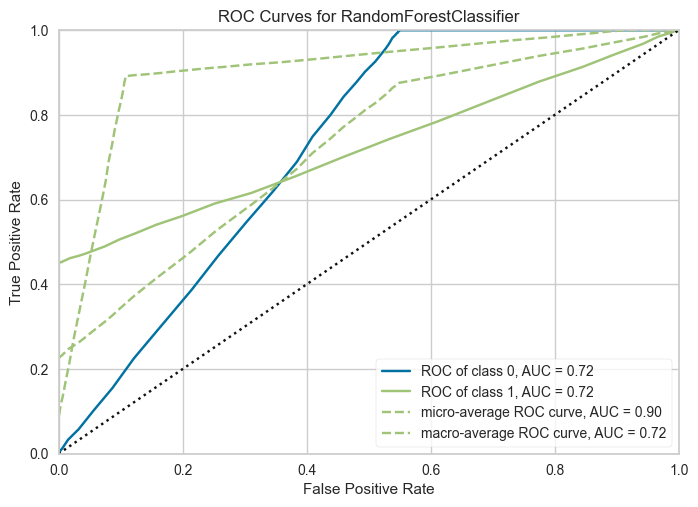

In [50]:
eng_exp.plot_model(eng_model, plot="auc")

## Evaluation of Feature Engineering
The engineered features were not beneficial for this dataset and model setup. Rather than improving predictive performance, they introduced additional complexity by increasing the number of features without providing meaningful new information. This resulted in longer training times while offering little to no improvement in evaluation metrics, and in some cases, slightly reduced model performance. Overall, the engineered features were not effective, and a simple data cleaning approach using the original features produced better results. Therefore, the cleaned dataset was selected as the final dataset for model development due to its comparable predictive performance, lower computational cost, and simpler feature set.

In [52]:
df = df_cleaned.sort_values("timestamp").reset_index(drop=True)
dates = sorted(df["timestamp"].dt.normalize().unique())
train_dates = dates[:60]
test_dates = dates[60:]

train = df[df["timestamp"].dt.normalize().isin(train_dates)]
test = df[df["timestamp"].dt.normalize().isin(test_dates)]

In [57]:
time_exp = ClassificationExperiment()

time_exp.setup(
    data=train,
    test_data=test,
    target=cfg.data.target_column,
    session_id=cfg.model.session_id,
    ignore_features=cfg.model.ignore_features,
    experiment_name="Temporal_Analysis",
    log_experiment=True,
    html=False,
    verbose=False
)

time_model = time_exp.compare_models(verbose=False)
time_results = time_exp.pull().copy()

2026/07/27 23:17:04 INFO mlflow.tracking._tracking_service.client: 🏃 View run Session Initialized 7bad at: http://127.0.0.1:5000/#/experiments/483495912691625471/runs/3af89c32a190407b9b9216b03a0d0af1.
2026/07/27 23:17:04 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/483495912691625471.
2026/07/27 23:18:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/07/27 23:18:30 INFO mlflow.tracking._tracking_service.client: 🏃 View run Extra Trees Classifier at: http://127.0.0.1:5000/#/experiments/457390336666443382/runs/b53313e07cf14d8788726310b5c51900.
2026/07/27 23:18:30 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/457390336666443382.
2026/07/27 23:18:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `i

In [ ]:
print("\n=== Temporal Analysis ===")
print(time_results)

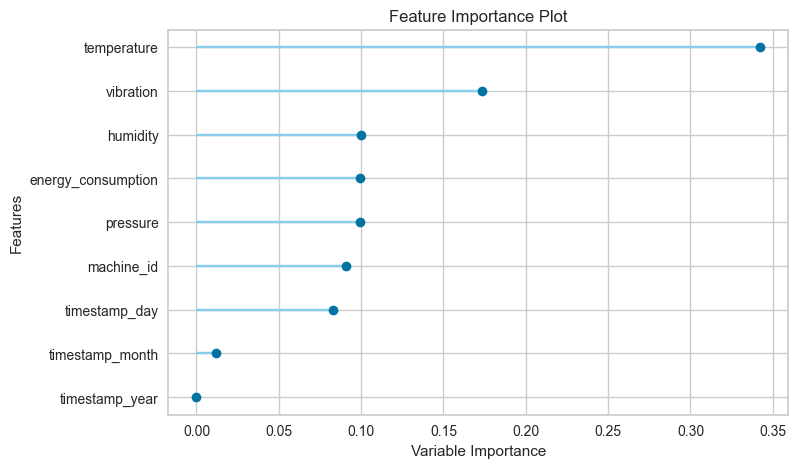

In [59]:
time_exp.plot_model(time_model, plot="feature")

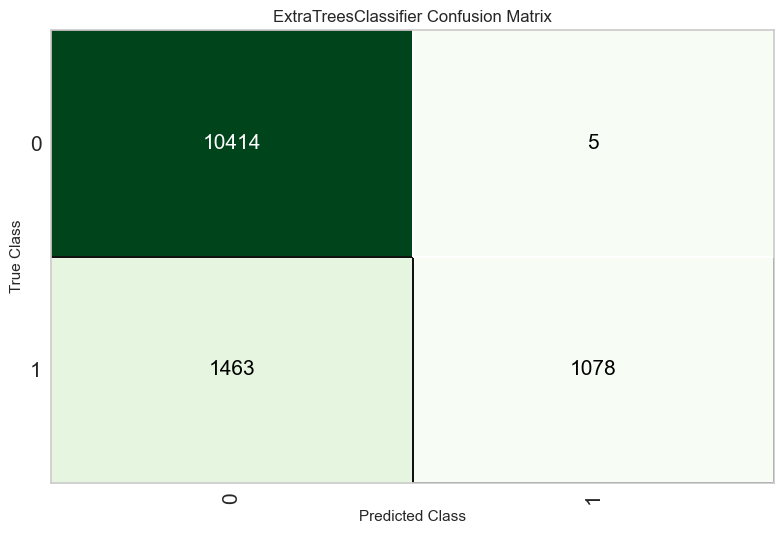

In [60]:
time_exp.plot_model(time_model, plot="confusion_matrix")

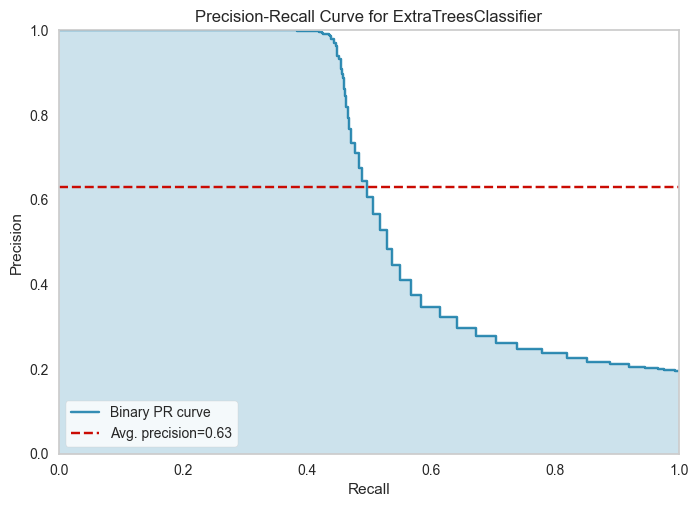

In [58]:
time_exp.plot_model(time_model, plot="pr")